---
title: Multiobjective Optimisation with Weights
image: image.png
toc: true
execute: 
  enabled: true
---

There are a few different ways we can handle multiple competing objectives that we need to balance. 

In lokigi, by default, we will weight a p-median problem on *demand*. 

Let's imagine we have two regions, A and B. 

We are trying out a combination of 3 sites. 

Region A has an expected demand of 100 people per month. In this solution, we see that the journey time to their nearest centre is 10 minutes. 

Region B has an expected demand of 500 people per month. In this solution, the journey time to their nearest centre is 40 minutes. 


Now we look at another solution. For region A, the time is now 20 minutes. For region B, the time is now 15 minutes. 

While this is worse for the people in region A, more people in region B will benefit, bringing the average travel time across all people down. 

This can lead to a better solution overall than assuming demand is equal across a region. 


But what happens if demand isn't the only thing we care about? 

What if we want to put more importance on improving access in the most deprived areas, for example? 

Using additional weights can help us to do this. 

:::{.callout-note}
While lokigi offers weights as an option for multi-objective problems, weights have a few drawbacks:

- they can be quite opaque and challenging to understand for stakeholders
- they can have limited effect on the outcome

Therefore you may wish to consider alternative approaches to multiobjective optimisation, such as those shown in the sections [comparing two solutions](../comparing_solutions/index.ipynb) and [pareto optimisation](../multiobjective_optimisation_pareto/index.ipynb).
:::

In [1]:
from lokigi.site import SiteProblem

problem = SiteProblem()

problem.add_sites(
    "../../../sample_data/devon_cdcs.csv",
    candidate_id_col="Facility_Name",
    vertical_geometry_col="Latitude",
    horizontal_geometry_col="Longitude",
    required_sites_col="Existing"
    )

problem.add_region_geometry_layer(
    "../../../sample_data/LSOA_Devon_2021_EW_BSC_V4.gpkg",
    common_col="LSOA21NM"
    )

problem.add_travel_matrix(
    travel_matrix_df="../../../sample_data/travel_matrix_car_devon_cdcs.csv",
    source_col="from_id",
    unit="minutes",
    )

problem.add_demand(
    "../../../sample_data/demand_MF_50_84.csv",
    demand_col="Total",
    location_id_col="LSOA 2021 Name"
    )

problem.add_equity_data(
    "../../../sample_data/devon_imd_2025_2021_LSOAs.csv",
    equity_col="Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA",
    common_col="LSOA name (2021)",
    label="IMD Decile (1 = most deprived)"
    )

Guessed CRS: EPSG:4326 (Values fall within longitude/latitude bounds)


<Axes: >

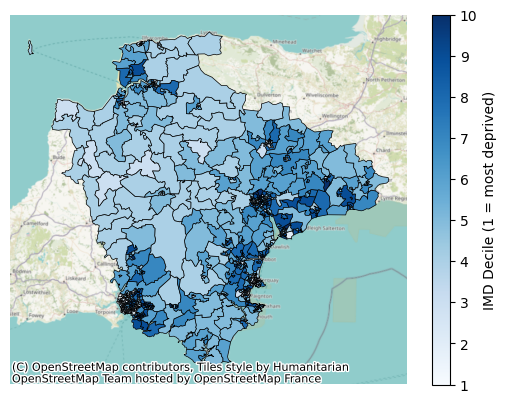

In [2]:
problem.plot_region_geometry_layer(plot_equity=True)

<Axes: >

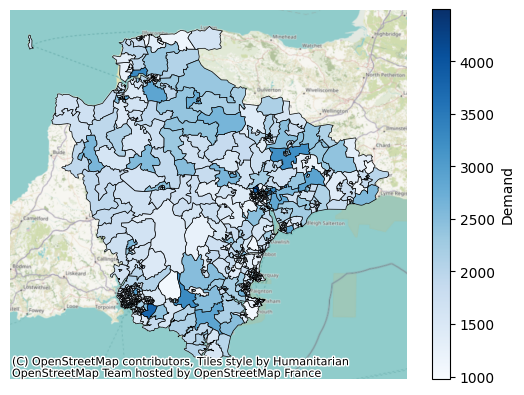

In [3]:
problem.plot_region_geometry_layer(plot_demand=True)

C:\Users\Sammi\AppData\Local\Temp\ipykernel_49320\3888362976.py:1: UserWarning: Unable to download background map tiles (ReadTimeout). Continuing without a basemap.
  problem.plot_sites()


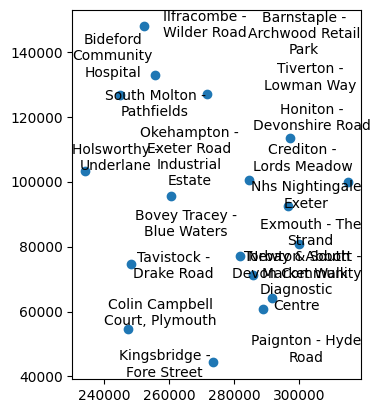

In [4]:
problem.plot_sites()

# Weighting by demand, equity, or both

The default behaviour in lokigi, if no weights are stated for a standard (unsimplified) p-median problem

As a reminder, an unsimplified p-median problem will solve for raw travel times rather than applying any weighting. 

In [5]:
solution_standard_demand_weighted_p_median = problem.solve(p=5, objectives="p_median", threshold_for_coverage=30)
solution_standard_demand_weighted_p_median.show_solutions(n_best=3)

  0%|          | 0/14 [00:00<?, ?it/s]

,solution_rank,site_names,site_indices,unselected_site_names,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,total_cost,...,gap_relative_weighted,avg_lower_third_bins,avg_middle_third_bins,avg_upper_third_bins,inter_tertile_ratio,gap_absolute_description,gap_relative_description,inter_tertile_description,problem_df,additional_site_names
0,1,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 12]","[Tiverton - Lowman Way, Okehampton - Exeter Ro...",30,20.23,20.03,39.41,61.53,NaN,...,2.65,15.86,23.18,17.60,0.90,Spread of 16.2 minutes between best and worst ...,Significant Disparity (Worst group travels 165...,Slightly Progressive (Most deprived travel 10%...,LSOA 2021 Name Bideford Community Hospi...,[Barnstaple - Archwood Retail Park]
1,2,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 5]","[Tiverton - Lowman Way, Crediton - Lords Meado...",30,20.43,20.37,37.61,61.53,NaN,...,2.18,16.40,23.46,18.08,0.91,Spread of 13.6 minutes between best and worst ...,Significant Disparity (Worst group travels 118...,Slightly Progressive (Most deprived travel 9% ...,LSOA 2021 Name Bideford Community Hospi...,[Okehampton - Exeter Road Industrial Estate]
2,3,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 8]","[Tiverton - Lowman Way, Okehampton - Exeter Ro...",30,20.44,20.21,42.07,61.18,NaN,...,2.23,16.86,23.17,17.04,0.99,Spread of 14.2 minutes between best and worst ...,Significant Disparity (Worst group travels 123...,Balanced (Macro travel times are broadly equal),LSOA 2021 Name Bideford Community Hospi...,[Newton Abbott - Market Walk]


In [6]:
solution_standard_demand_weighted_p_median.show_solutions().sort_values('inter_tertile_ratio').head(3)

,solution_rank,site_names,site_indices,unselected_site_names,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,total_cost,...,gap_relative_weighted,avg_lower_third_bins,avg_middle_third_bins,avg_upper_third_bins,inter_tertile_ratio,gap_absolute_description,gap_relative_description,inter_tertile_description,problem_df,additional_site_names
0,1,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 12]","[Tiverton - Lowman Way, Okehampton - Exeter Ro...",30,20.23,20.03,39.41,61.53,NaN,...,2.65,15.86,23.18,17.60,0.90,Spread of 16.2 minutes between best and worst ...,Significant Disparity (Worst group travels 165...,Slightly Progressive (Most deprived travel 10%...,LSOA 2021 Name Bideford Community Hospi...,[Barnstaple - Archwood Retail Park]
1,2,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 5]","[Tiverton - Lowman Way, Crediton - Lords Meado...",30,20.43,20.37,37.61,61.53,NaN,...,2.18,16.40,23.46,18.08,0.91,Spread of 13.6 minutes between best and worst ...,Significant Disparity (Worst group travels 118...,Slightly Progressive (Most deprived travel 9% ...,LSOA 2021 Name Bideford Community Hospi...,[Okehampton - Exeter Road Industrial Estate]
12,13,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 16]","[Tiverton - Lowman Way, Okehampton - Exeter Ro...",30,20.94,20.84,39.84,61.53,NaN,...,2.34,16.42,24.40,18.12,0.91,Spread of 15.4 minutes between best and worst ...,Significant Disparity (Worst group travels 134...,Slightly Progressive (Most deprived travel 9% ...,LSOA 2021 Name Bideford Community Hospi...,[Holsworthy - Underlane]


In [7]:
solution_standard_demand_weighted_p_median.show_solutions().sort_values('inter_tertile_ratio', ascending=False).head(3)

,solution_rank,site_names,site_indices,unselected_site_names,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,total_cost,...,gap_relative_weighted,avg_lower_third_bins,avg_middle_third_bins,avg_upper_third_bins,inter_tertile_ratio,gap_absolute_description,gap_relative_description,inter_tertile_description,problem_df,additional_site_names
8,9,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 10]","[Tiverton - Lowman Way, Okehampton - Exeter Ro...",30,20.72,20.51,39.44,61.53,NaN,...,2.26,17.35,23.21,17.23,1.01,Spread of 14.6 minutes between best and worst ...,Significant Disparity (Worst group travels 126...,Balanced (Macro travel times are broadly equal),LSOA 2021 Name Bideford Community Hospi...,[Honiton - Devonshire Road]
13,14,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 11]","[Tiverton - Lowman Way, Okehampton - Exeter Ro...",30,21.03,20.85,42.40,61.53,NaN,...,2.33,17.15,24.11,17.17,1.00,Spread of 15.3 minutes between best and worst ...,Significant Disparity (Worst group travels 133...,Balanced (Macro travel times are broadly equal),LSOA 2021 Name Bideford Community Hospi...,[Exmouth - The Strand]
2,3,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 8]","[Tiverton - Lowman Way, Okehampton - Exeter Ro...",30,20.44,20.21,42.07,61.18,NaN,...,2.23,16.86,23.17,17.04,0.99,Spread of 14.2 minutes between best and worst ...,Significant Disparity (Worst group travels 123...,Balanced (Macro travel times are broadly equal),LSOA 2021 Name Bideford Community Hospi...,[Newton Abbott - Market Walk]


## Weighting by equity instead

We can instead weight by equity by passing in a dictionary of weights. 

In [8]:
solution_equity_weighted_p_median = problem.solve(p=5, objectives="p_median", weights={'equity': 1.0}, threshold_for_coverage=30)
solution_equity_weighted_p_median.show_solutions(n_best=3)

  0%|          | 0/14 [00:00<?, ?it/s]

,solution_rank,site_names,site_indices,unselected_site_names,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,total_cost,...,gap_relative_weighted,avg_lower_third_bins,avg_middle_third_bins,avg_upper_third_bins,inter_tertile_ratio,gap_absolute_description,gap_relative_description,inter_tertile_description,problem_df,additional_site_names
0,1,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 12]","[Tiverton - Lowman Way, Okehampton - Exeter Ro...",30,19.57,20.03,39.41,61.53,NaN,...,2.49,15.90,22.81,17.81,0.89,Spread of 15.3 minutes between best and worst ...,Significant Disparity (Worst group travels 149...,Slightly Progressive (Most deprived travel 11%...,LSOA 2021 Name Bideford Community Hospi...,[Barnstaple - Archwood Retail Park]
1,2,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 5]","[Tiverton - Lowman Way, Crediton - Lords Meado...",30,19.91,20.37,37.61,61.53,NaN,...,2.05,16.65,23.19,18.33,0.91,Spread of 12.8 minutes between best and worst ...,Significant Disparity (Worst group travels 105...,Slightly Progressive (Most deprived travel 9% ...,LSOA 2021 Name Bideford Community Hospi...,[Okehampton - Exeter Road Industrial Estate]
2,3,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 17]","[Tiverton - Lowman Way, Okehampton - Exeter Ro...",30,19.99,20.37,41.91,61.18,NaN,...,2.28,16.61,22.80,18.00,0.92,Spread of 14.2 minutes between best and worst ...,Significant Disparity (Worst group travels 128...,Slightly Progressive (Most deprived travel 8% ...,LSOA 2021 Name Bideford Community Hospi...,[Paignton - Hyde Road]


## Weighting by both demand and equity

In [9]:
solution_equity_and_demand_weighted_p_median = problem.solve(
    p=5, objectives="p_median", weights={'equity': 1.0, 'demand': 1.0}, threshold_for_coverage=30,
    )
solution_equity_and_demand_weighted_p_median.show_solutions(n_best=3)

  0%|          | 0/14 [00:00<?, ?it/s]

,solution_rank,site_names,site_indices,unselected_site_names,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,total_cost,...,gap_relative_weighted,avg_lower_third_bins,avg_middle_third_bins,avg_upper_third_bins,inter_tertile_ratio,gap_absolute_description,gap_relative_description,inter_tertile_description,problem_df,additional_site_names
0,1,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 12]","[Tiverton - Lowman Way, Okehampton - Exeter Ro...",30,19.84,20.03,39.41,61.53,NaN,...,2.56,15.90,23.08,17.46,0.91,Spread of 15.8 minutes between best and worst ...,Significant Disparity (Worst group travels 156...,Slightly Progressive (Most deprived travel 9% ...,LSOA 2021 Name Bideford Community Hospi...,[Barnstaple - Archwood Retail Park]
1,2,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 5]","[Tiverton - Lowman Way, Crediton - Lords Meado...",30,20.08,20.37,37.61,61.53,NaN,...,2.11,16.55,23.40,17.94,0.92,Spread of 13.2 minutes between best and worst ...,Significant Disparity (Worst group travels 111...,Slightly Progressive (Most deprived travel 8% ...,LSOA 2021 Name Bideford Community Hospi...,[Okehampton - Exeter Road Industrial Estate]
2,3,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 4]","[Okehampton - Exeter Road Industrial Estate, C...",30,20.17,20.39,41.07,61.53,NaN,...,2.21,16.47,23.35,17.61,0.94,Spread of 14.3 minutes between best and worst ...,Significant Disparity (Worst group travels 121...,Slightly Progressive (Most deprived travel 6% ...,LSOA 2021 Name Bideford Community Hospi...,[Tiverton - Lowman Way]


# Additional datasets

Let's now add an additional dataset. We're going to add in demand for patients 50-84. 

In [10]:
problem.add_additional_data(
    df="../../../sample_data/demand_MF_50_84.csv",
    column_of_interest="MF50-84",
    common_col="LSOA 2021 Name",
    label="Demand 50-84",
    direction="higher_better"
    )

In [11]:
solution_additional_dataset_weighted_p_median = problem.solve(
    p=5, objectives="p_median", weights={'equity': 0.1, 'demand': 0.1, 'Demand 50-84': 0.6}, threshold_for_coverage=30
    )
solution_equity_and_demand_weighted_p_median.show_solutions(n_best=3)

  0%|          | 0/14 [00:00<?, ?it/s]

,solution_rank,site_names,site_indices,unselected_site_names,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,total_cost,...,gap_relative_weighted,avg_lower_third_bins,avg_middle_third_bins,avg_upper_third_bins,inter_tertile_ratio,gap_absolute_description,gap_relative_description,inter_tertile_description,problem_df,additional_site_names
0,1,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 12]","[Tiverton - Lowman Way, Okehampton - Exeter Ro...",30,19.84,20.03,39.41,61.53,NaN,...,2.56,15.90,23.08,17.46,0.91,Spread of 15.8 minutes between best and worst ...,Significant Disparity (Worst group travels 156...,Slightly Progressive (Most deprived travel 9% ...,LSOA 2021 Name Bideford Community Hospi...,[Barnstaple - Archwood Retail Park]
1,2,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 5]","[Tiverton - Lowman Way, Crediton - Lords Meado...",30,20.08,20.37,37.61,61.53,NaN,...,2.11,16.55,23.40,17.94,0.92,Spread of 13.2 minutes between best and worst ...,Significant Disparity (Worst group travels 111...,Slightly Progressive (Most deprived travel 8% ...,LSOA 2021 Name Bideford Community Hospi...,[Okehampton - Exeter Road Industrial Estate]
2,3,"[Bideford Community Hospital, NHS Nightingale ...","[0, 1, 2, 3, 4]","[Okehampton - Exeter Road Industrial Estate, C...",30,20.17,20.39,41.07,61.53,NaN,...,2.21,16.47,23.35,17.61,0.94,Spread of 14.3 minutes between best and worst ...,Significant Disparity (Worst group travels 121...,Slightly Progressive (Most deprived travel 6% ...,LSOA 2021 Name Bideford Community Hospi...,[Tiverton - Lowman Way]


In [12]:
solution_additional_dataset_weighted_p_median.show_solutions().iloc[0]['problem_df']

,LSOA 2021 Name,Bideford Community Hospital,NHS Nightingale Exeter,"Colin Campbell Court, Plymouth",Torbay & South Devon Community Diagnostic Centre,Barnstaple - Archwood Retail Park,min_cost,selected_site,within_threshold,Total,Demand 50-84,LSOA name (2021),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOA
0,Plymouth 001A,103.350000,71.266670,15.883333,72.750000,109.933334,15.883333,"Colin Campbell Court, Plymouth",True,1712,850,Plymouth 001A,10
1,Plymouth 002A,105.633330,71.416664,16.033333,72.916664,112.216670,16.033333,"Colin Campbell Court, Plymouth",True,1669,698,Plymouth 002A,8
2,Plymouth 003A,108.600000,72.000000,15.500000,73.500000,115.183334,15.500000,"Colin Campbell Court, Plymouth",True,1750,630,Plymouth 003A,2
3,Plymouth 003B,110.533330,73.900000,17.433332,75.383330,117.116670,17.433332,"Colin Campbell Court, Plymouth",True,1493,498,Plymouth 003B,2
4,Plymouth 003C,112.100000,75.416664,19.000000,76.916664,118.683334,19.000000,"Colin Campbell Court, Plymouth",True,1740,444,Plymouth 003C,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
724,Torbay 013I,115.350000,46.650000,58.516666,20.066668,118.750000,20.066668,Torbay & South Devon Community Diagnostic Centre,True,2670,576,Torbay 013I,5
725,Torridge 002D,9.083333,92.700000,123.016670,117.866670,19.966667,9.083333,Bideford Community Hospital,True,1090,628,Torridge 002D,4
726,Torridge 002E,9.700000,93.850000,124.166664,119.016670,21.116667,9.700000,Bideford Community Hospital,True,1561,759,Torridge 002E,5
727,West Devon 001E,51.783333,65.883330,83.883330,91.716670,58.416668,51.783333,Bideford Community Hospital,False,1609,797,West Devon 001E,4
